# Analiza zachowań konsumenckich oraz ocena efektywności sprzedaży w sektorze e-commerce
## 1. Cel projektu
Projekt koncentruje się na kompleksowej analizie danych pochodzących z platformy e-commerce w celu identyfikacji i zrozumienia kluczowych aspektów zachowań konsumenckich. W szczególności obejmuje analizę procesów zakupowych, charakterystyk demograficznych klientów oraz ocenę rentowności oferowanych produktów.

Głównym celem projektu jest przekształcenie surowych danych transakcyjnych w uporządkowane i użyteczne informacje, które umożliwią formułowanie trafnych wniosków strategicznych. Uzyskane rezultaty mają wspierać podejmowanie decyzji biznesowych oraz przyczyniać się do optymalizacji działań sprzedażowych i zwiększenia efektywności funkcjonowania platformy.

## 2. Pytania badawcze

* <a href="#1">Czy istnieją wyraźne różnice w wartości koszyka między krajami?</a> 
* <a href="#2">Czy płeć klienta jest czynnikiem różnicującym wartość składanych zamówień, i czy ten efekt utrzymuje się lub zmienia w kolejnych latach w obrębie tej samej grupy wiekowej?</a> 
* <a href="#3">Które kategorie produktów niosą największe ryzyko finansowe z tytułu zwrotów, biorąc pod uwagę zarówno liczbę zwrotów, jak i wartość zwracanych produktów? </a>

## 3. O zbiorze danych
* <b>Źródło:</b> <a href="https://console.cloud.google.com/marketplace/product/bigquery-public-data/thelook-ecommerce?hl=en&project=single-ripsaw-431211-q0">Google BigQuery (Public Datasets)</a> 

* <b>Typ danych:</b> Syntetyczne dane e-commerce (wspójność logiczna).

* <b>Zakres:</b> 4 tabele relacyjne (Users, Products, Orders, Order Items).





In [13]:
# Import bibliotek
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine,inspect,text
from dotenv import load_dotenv


In [14]:
# Wczytanie danych z pliku .env
load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

In [15]:
# Ustawienie parametrów wykresów
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.spines.top'] = False   
plt.rcParams['axes.spines.right'] = False  
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = '#f9f9f9'

In [16]:
# Połączenie z bazą danych
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [17]:
def safe_import_data():
    files = {
        'users.csv': 'users',
        'products.csv': 'products',
        'orders.csv': 'orders',
        'order_items.csv': 'order_items'
    }
    
    inspector = inspect(engine)
    
    for file_name, table_name in files.items():
        try:
            # 1. Sprawdzamy czy tabela w ogóle istnieje
            if not inspector.has_table(table_name):
                print(f"❌ Błąd: Tabela '{table_name}' nie istnieje! Uruchom najpierw schema.sql w bazie.")
                continue

            # 2. Sprawdzamy czy tabela jest pusta
            count = pd.read_sql(f"SELECT COUNT(*) FROM {table_name}", engine).iloc[0, 0]
            
            if count > 0:
                print(f"⏭️ Pominięto: Tabela '{table_name}' ma już dane ({count} wierszy).")
                continue

            # 3. Jeśli istnieje i jest pusta - wgrywamy
            print(f"⏳ Wgrywanie danych do puste tabeli '{table_name}' z pliku {file_name}...")
            df = pd.read_csv(file_name)
            df.to_sql(table_name, engine, if_exists='append', index=False)
            print(f"✅ Sukces: Załadowano {len(df)} wierszy.")

        except Exception as e:
            print(f"❌ Wystąpił błąd przy tabeli {table_name}: {e}")



In [18]:
safe_import_data()

⏭️ Pominięto: Tabela 'users' ma już dane (100000 wierszy).
⏭️ Pominięto: Tabela 'products' ma już dane (29094 wierszy).
⏭️ Pominięto: Tabela 'orders' ma już dane (125676 wierszy).
⏭️ Pominięto: Tabela 'order_items' ma już dane (182188 wierszy).


In [19]:
# Analiza brakujących danych (NA) w każdej tabeli
def analyze_na(engine, table):
    query = f"SELECT * FROM {table}"
    with engine.connect() as connection:
        df = pd.read_sql_query(query, connection)
    return df

tables = ['users', 'orders', 'products', 'order_items']

all_nas = {t: analyze_na(engine, t).isna().sum() for t in tables}

summary_df = pd.DataFrame(all_nas).fillna(0).astype(int)

final_report = summary_df[summary_df.sum(axis=1) > 0]

print("--- RAPORT BRAKUJĄCYCH DANYCH (TYLKO KOLUMNY Z NA) ---")
print(final_report)


--- RAPORT BRAKUJĄCYCH DANYCH (TYLKO KOLUMNY Z NA) ---
              users  orders  products  order_items
city           1016       0         0            0
delivered_at      0   82025         0       119005
returned_at       0  113249         0       164076
shipped_at        0   44173         0        64233


### Decyzja dotycząca brakujących danych 
* Kolumna `city` (tabela `users`):
Braki danych w tej kolumnie nie zostały usunięte, ponieważ kolumna ta nie odgrywa istotnej roli w kluczowych etapach analizy. Ich eliminacja mogłaby prowadzić do nieuzasadnionej utraty wartościowych informacji zawartych w pozostałych kolumnach.

* Tabele `orders` i `orders_items`:
Występujące tu braki (np. w datach dostarczenia czy zwrotu) mają charakter informacyjny – odzwierciedlają status zamówienia (np. zamówienia w trakcie realizacji, anulowane lub niezwrócone). 
Zastępowanie ich lub usuwanie rekordów byłoby błędem merytorycznym, dlatego zostały zachowane w celu poprawnej interpretacji procesów logistycznych.

* W tabeli `products` zdecydowano o usunięciu rekordów zawierających braki danych w kolumnie `brand` oraz `name`. Działanie to ma na celu zapewnienie pełnej spójności katalogu produktów oraz wyeliminowanie niekompletnych informacji,


In [20]:
with engine.connect() as conn:
    conn.execute(text("""
        DELETE FROM order_items 
        WHERE product_id IN (SELECT id FROM products WHERE brand IS NULL OR name IS NULL);
    """))
    
    conn.execute(text("DELETE FROM products WHERE brand IS NULL;"))
    conn.execute(text("DELETE FROM products WHERE name IS NULL;"))
    
    conn.commit()
    print("✅ Pomyślnie usunięto produkty oraz powiązane z nimi pozycje zamówień.")

✅ Pomyślnie usunięto produkty oraz powiązane z nimi pozycje zamówień.


In [21]:
# Sprawdzenie liczby wierszy z NA po usunięciu rekordów
df = pd.read_sql_query("SELECT * FROM products WHERE name IS NULL OR brand IS NULL", engine)
print(f"Liczba wierszy z NA: {len(df)}")

Liczba wierszy z NA: 0


<h2 id=1 style="text-decoration:underline">Czy istnieją wyraźne różnice w wartości koszyka między krajami?</h1>

In [22]:
# Analiza średniej wartości koszyka według krajów w danym miesiącu i roku, z możliwością filtrowania po wieku użytkowników
def analyze_average_order_value(engine, month, year, min_age=0, max_age=100):
    query = f"""
    SELECT
        u.country AS kraj,
        COUNT(oi.id) AS ilosc_zamowien,
        ROUND(AVG(oi.sale_price)::numeric, 2) AS srednia_wartosc_koszyka
    FROM users AS u
    JOIN order_items AS oi ON u.id = oi.user_id
    JOIN orders AS o ON oi.order_id = o.order_id 
    WHERE EXTRACT(MONTH FROM o.created_at) = {month}
      AND EXTRACT(YEAR FROM o.created_at) = {year}
      AND oi.returned_at IS NULL
      AND oi.shipped_at IS NOT NULL
      AND (u.age BETWEEN {min_age} AND {max_age})
    GROUP BY u.country
    ORDER BY srednia_wartosc_koszyka DESC;
    """

    df = pd.read_sql_query(query, engine)

    ax = sns.barplot(
        x='kraj',
        y='srednia_wartosc_koszyka',
        data=df,
        color='#2d6a4f'
    )

    for index, row in df.iterrows():
        value = row['srednia_wartosc_koszyka']
        count = row['ilosc_zamowien']

        # wartość średnia (góra słupka)
        ax.text(index,value + 0.3,f"{value}",ha='center',va='bottom',fontsize=10,fontweight='bold')

        # ilość zamówień (środek słupka)
        ax.text(index,value / 2,f"n={count}",ha='center',va='center',fontsize=9,color='white',fontweight='bold')

    plt.title(
        f"""Średnia wartość koszyka według krajów
        (Wiek: {min_age} - {max_age}) | {year}"""
    )
    plt.xlabel('Kraj')
    plt.ylabel('Średnia wartość koszyka')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

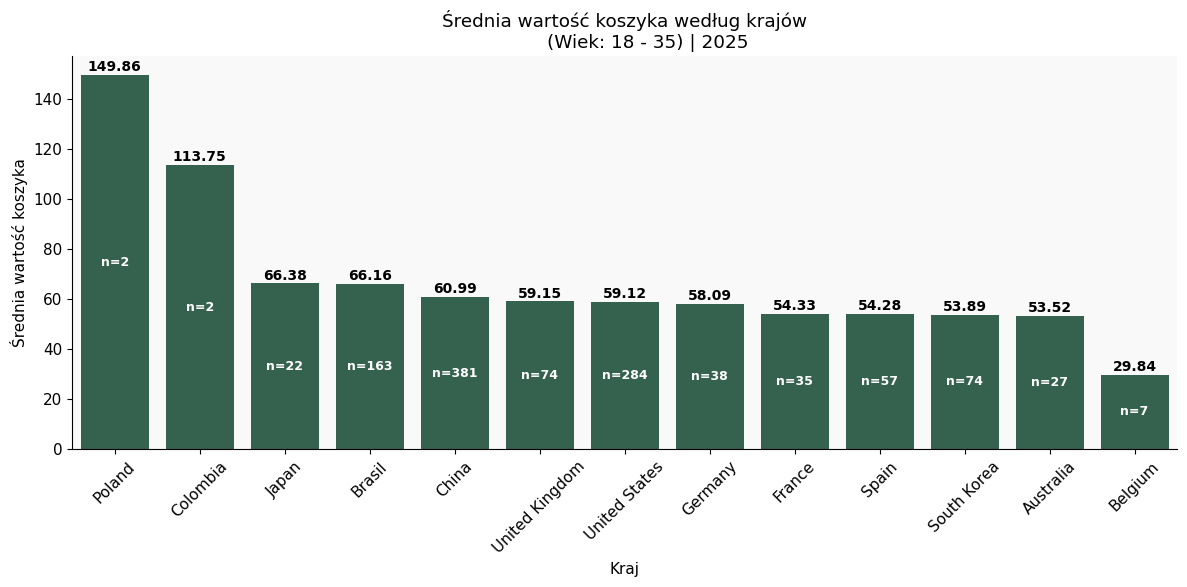

In [23]:
analyze_average_order_value(engine, month=12, year=2025, min_age=18, max_age=35)

### Analiza średniej wartości koszyka (AOV) w przedziale wiekowym 18-35 – Grudzień 2025 

Mimo że na wykresie najwyższe wartości odnotowano dla Polski (149,86$) oraz Kolumbii (113,75$), wyniki te należy uznać za statystycznie nieistotne. W obu przypadkach liczba zamówień wynosi zaledwie 2, co oznacza, że pojedyncza transakcja o wysokiej wartości mogła całkowicie zaburzyć średnią, nie oddając rzeczywistego potencjału tych rynków.

Pierwszym krajem, w przypadku którego próba badawcza pozwala na wyciągnięcie rzetelnych wniosków, jest Brazylia. Przy znaczącej liczbie 163 zamówień, średnia wartość koszyka wyniosła tam 66.16$, co czyni ten rynek najbardziej dochodowym w zestawieniu z rynkami o ustabilizowanej pozycji.

Największą bazę transakcyjną odnotowano w Chinach n = 381 oraz USA n = 284 jednak tamtejszy średni koszyk jest o ok. 10% niższy niż w Brazylii i oscyluje wokół wartości 61-59.

Zasadne jest uruchomienie ukierunkowanych działań marketingowych w Polsce i Kolumbii. Celem byłoby zwiększenie liczby zamówień, co pozwoli sprawdzić, czy wysoka wartość koszyka utrzyma się przy większej skali sprzedaży.


<h2 id=2 style="text-decoration:underline"> Czy płeć klienta jest czynnikiem różnicującym wartość składanych zamówień, i czy ten efekt utrzymuje się lub zmienia w kolejnych latach w obrębie tej samej grupy wiekowej?</h2>

In [24]:
# Analiza średniej wartości zamówienia według płci użytkowników w danym roku, z możliwością filtrowania po wieku
def gender_order_analysis(engine, year, min_age=0, max_age=100):

    query = f"""SELECT
        CASE
            WHEN u.gender = 'M' THEN 'Mezczyzni'
            WHEN u.gender = 'F' THEN 'Kobiety'
            ELSE 'Inna plec'
        END AS Plec,
        ROUND(AVG(oi.total_value)::numeric, 2) AS Srednia_wartosc_zamowienia
    FROM users AS u
    JOIN orders AS o ON u.id = o.user_id
    JOIN (
        SELECT
            order_id,
            SUM(sale_price) AS total_value
        FROM order_items
        GROUP BY order_id
    ) AS oi ON o.order_id = oi.order_id
    WHERE u.age BETWEEN {min_age} AND {max_age}
    AND o.created_at BETWEEN '{year}-01-01' AND '{year}-12-31'
    GROUP BY u.gender
    ORDER BY Plec;"""

    df = pd.read_sql_query(query, engine)
    return df


In [25]:
min_age = 18
max_age = 35
gender_24 = gender_order_analysis(engine, year=2024, min_age=min_age, max_age=max_age)
gender_25 = gender_order_analysis(engine, year=2025, min_age=min_age, max_age=max_age)

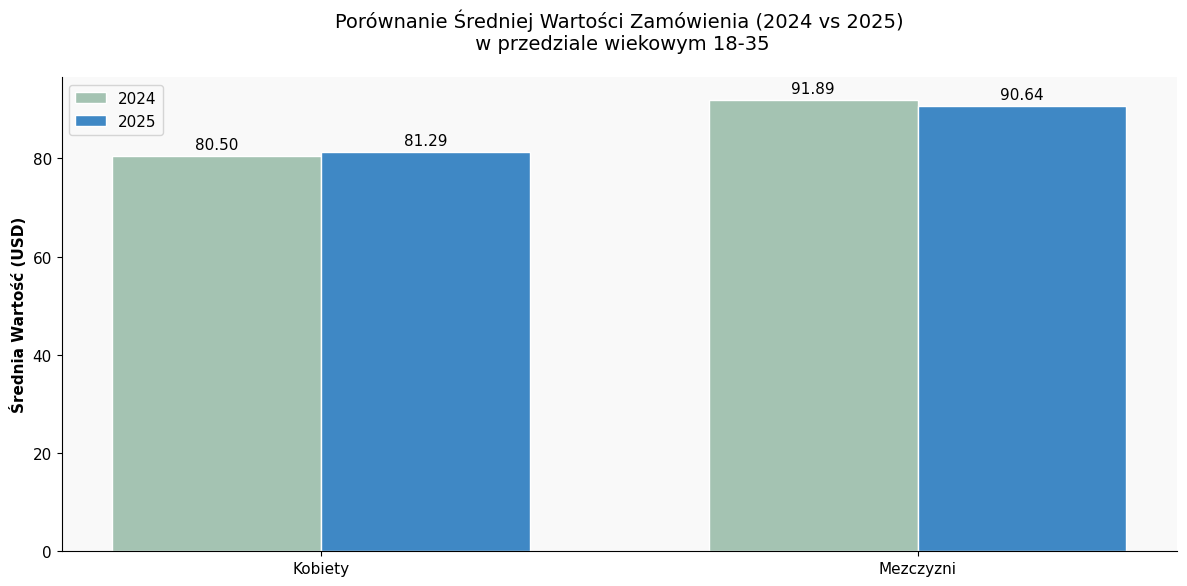

In [26]:
# Funkcja do porównania średniej wartości zamówienia według płci użytkowników w latach 2024 i 2025
def painting_gender_comparison(data_1, data_2):
    labels = data_1['plec']
    val_2024 = data_1['srednia_wartosc_zamowienia']
    val_2025 = data_2['srednia_wartosc_zamowienia']

    x = np.arange(len(labels))  
    width = 0.35                


    fig, ax = plt.subplots()

    rects1 = ax.bar(x - width/2, val_2024, width, label='2024', color='#a4c3b2', edgecolor='white')
    rects2 = ax.bar(x + width/2, val_2025, width, label='2025', color='#3f88c5', edgecolor='white')

    ax.set_ylabel('Średnia Wartość (USD)', fontweight='bold')
    ax.set_title(f'Porównanie Średniej Wartości Zamówienia (2024 vs 2025)\n w przedziale wiekowym {min_age}-{max_age}', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')

    plt.tight_layout()
    plt.show()

painting_gender_comparison(gender_24,gender_25)

### Analiza średniej wartości koszyka (AOV) klientów w przedziale wiekowym 18–35 lat (2024 vs 2025).

Dane wskazują na rozbieżne trendy w zależności od płci. Wśród kobiet średnia wartość zamówienia wzrosła z 80,50 USD w 2024 roku do 81,29 USD w 2025 roku, co oznacza wzrost o 0,98% rok do roku. Z kolei w segmencie mężczyzn odnotowano niewielki spadek – z 91,89 USD do 90,64 USD, czyli o 1,36% r/r.

Pomimo że mężczyźni nadal generują wyższą średnią wartość koszyka, w 2025 roku widoczne jest wyraźne zmniejszenie różnicy między płciami. Luka ta zmniejszyła się z 11,39 USD w 2024 roku do 9,35 USD w 2025 roku.

Zaobserwowany trend może wskazywać na rosnącą siłę nabywczą kobiet w analizowanym przedziale wiekowym lub na skuteczniejsze dopasowanie oferty oraz działań cross-sellingowych do potrzeb tej grupy klientów.


<h2 id=3 style="text-decoration:underline">Które kategorie produktów niosą największe ryzyko finansowe z tytułu zwrotów, biorąc pod uwagę zarówno liczbę zwrotów, jak i wartość zwracanych produktów?</h2>

In [27]:
# Funkcja do obliczenia i wizualizacji procentowego udziału zwróconych produktów w stosunku do wszystkich zamówionych produktów
def procentage_returned_items(engine,year=None):
    query = f"""
        SELECT 
        count(*) AS wszystkie_produkty,
        SUM(CASE WHEN status = 'Returned' THEN 1 ELSE 0 END) AS ilosc_zwrotow,
        ROUND(SUM(CASE WHEN status = 'Returned' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS procent_zwrotow
        FROM order_items 
        WHERE created_at >='{year}-01-01' AND created_at <= '{year}-12-31';"""

    df = pd.read_sql_query(query, engine)

    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axis('off') 
    
    total = f'{df['wszystkie_produkty'].iloc[0]:,}'
    perc = f'{df['procent_zwrotow'].iloc[0]}%'
    returns = f'{df['ilosc_zwrotow'].iloc[0]:,}'

    
    plt.text(0.1, 0.9, f'Zamówienia w {year} roku', fontsize=12, color='Black', ha='center')

    plt.text(0.1, 0.6, 'Wszystkie produkty', fontsize=12, color='gray', ha='center')
    plt.text(0.1, 0.3, total, fontsize=24, fontweight='bold', ha='center')

    plt.text(0.5, 0.6, 'Ilość zwrotów', fontsize=12, color='gray', ha='center')
    plt.text(0.5, 0.3, returns, fontsize=24, fontweight='bold', ha='center')

    plt.text(0.9, 0.6, 'Wskaźnik zwrotów', fontsize=12, color='gray', ha='center')
    plt.text(0.9, 0.3, perc, fontsize=24, fontweight='bold', color='red', ha='center')
    
    plt.tight_layout()
    plt.show()

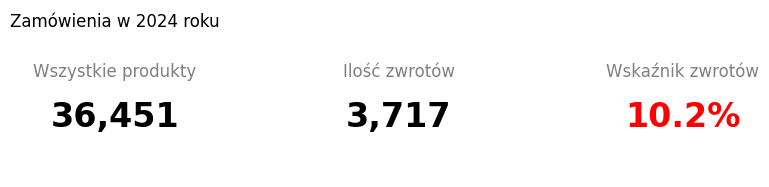

In [28]:
procentage_returned_items(engine, year=2024)

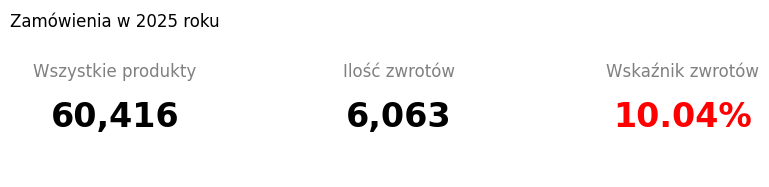

In [29]:
procentage_returned_items(engine, year=2025)

Analiza danych za rok 2025 wykazuje dynamiczny wzrost platformy. Kluczowym sukcesem jest skalowanie biznesu o 65,75%, przy jednoczesnym zachowaniu, a nawet lekkiej poprawie wskaźnika wzrotów.

* W roku 2024 wskaźnik wynosił `10,2%`

* W roku 2025 wskaźnik wynosił `10,04%`

Mimo wzrostu skali o ponad 23 tysiące sztuk produktów, system kontroli jakości i dopasowania produktu do potrzeb klienta zadziałał poprawnie. Spadek wskaźnika o 0,16 punktu procentowego jest sygnałem stabilizacji procesów posprzedażowych. Świadczy to o tym, że "ilość nie odbiła się negatywnie na jakości".

In [30]:
# Funkcja do analizy i wizualizacji najdroższych zwrotów z uwzględnieniem liczby produktów w danej kategorii (Top 10) w danym roku, z możliwością pokazania lub ukrycia wartości odstających
def analyze_returned_items(engine, year=None, show_outliers=False):
    query = f"""
        SELECT p.category AS kategoria, oi.sale_price::numeric AS cena
        FROM order_items oi
        JOIN products p ON oi.product_id = p.id
        WHERE oi.status = 'Returned'
        AND oi.created_at >= '{year}-01-01' AND oi.created_at <= '{year}-12-31';"""

    df = pd.read_sql_query(query, engine)

    counts = df['kategoria'].value_counts()
    top_categories = counts.nlargest(20).index
    df_plot = df[df['kategoria'].isin(top_categories)].copy()

    label_map = {cat: f'{cat} (n={counts[cat]})' for cat in top_categories}
    df_plot['kategoria_label'] = df_plot['kategoria'].map(label_map)

    median_order = (df_plot.groupby('kategoria_label')['cena']
                    .median()
                    .sort_values(ascending=False)
                    .index)


    plt.figure(figsize=(12, 9))
    ax = sns.boxplot(
        x='cena',
        y='kategoria_label',
        data=df_plot,
        order=median_order,
        hue='kategoria_label',
        legend=False,
        palette='Spectral',
        showfliers=show_outliers
    )

    if show_outliers:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(25))

    mean_basket = df_plot['cena'].mean()
    ax.axvline(
        x=mean_basket,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Średni koszyk: ${mean_basket:.2f}'
    )
    ax.legend(loc='lower right')

    plt.title(f'Najdroższe zwroty z uwzględnieniem liczby produktów (Top 10) w {year} roku')
    plt.xlabel('Cena (USD)', fontsize=12)
    plt.ylabel('Kategoria (n= liczba zwrotów)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

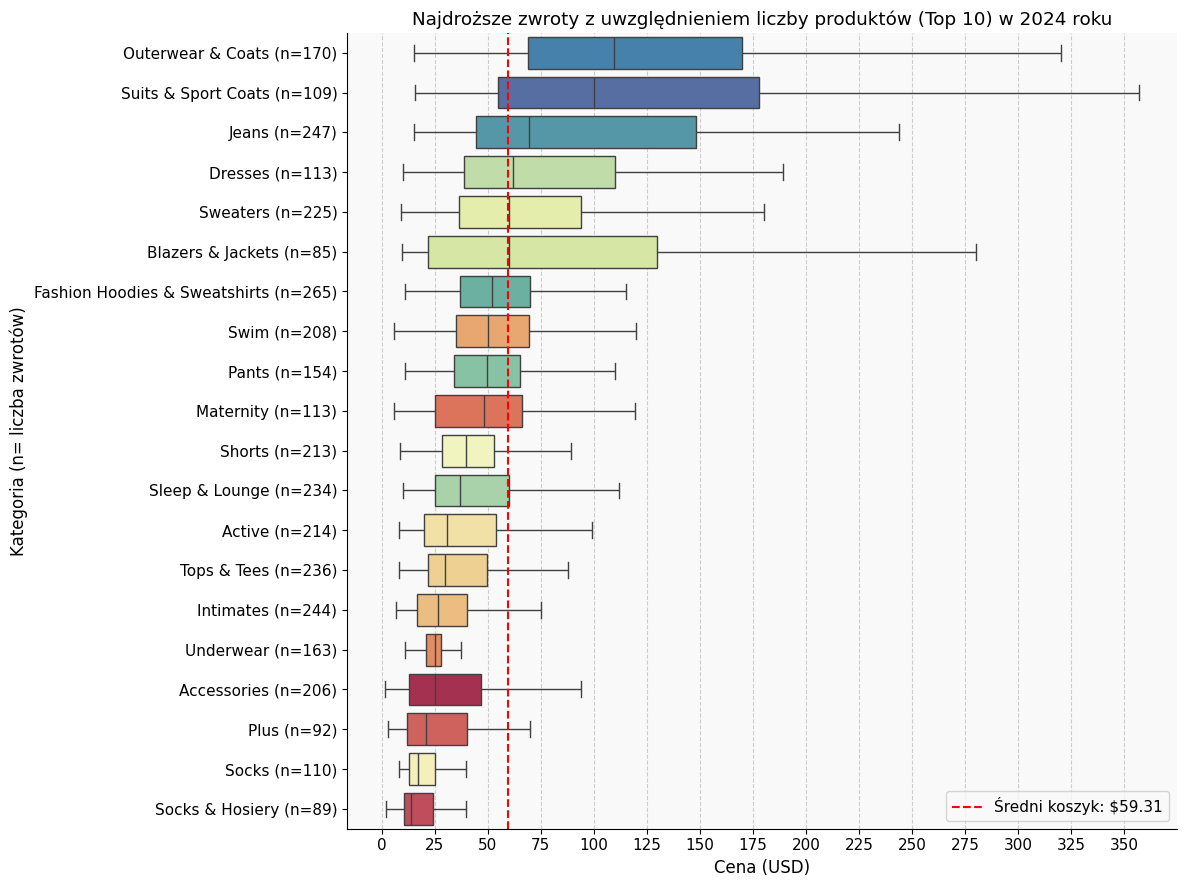

In [31]:
analyze_returned_items(engine, year=2024, show_outliers=False)

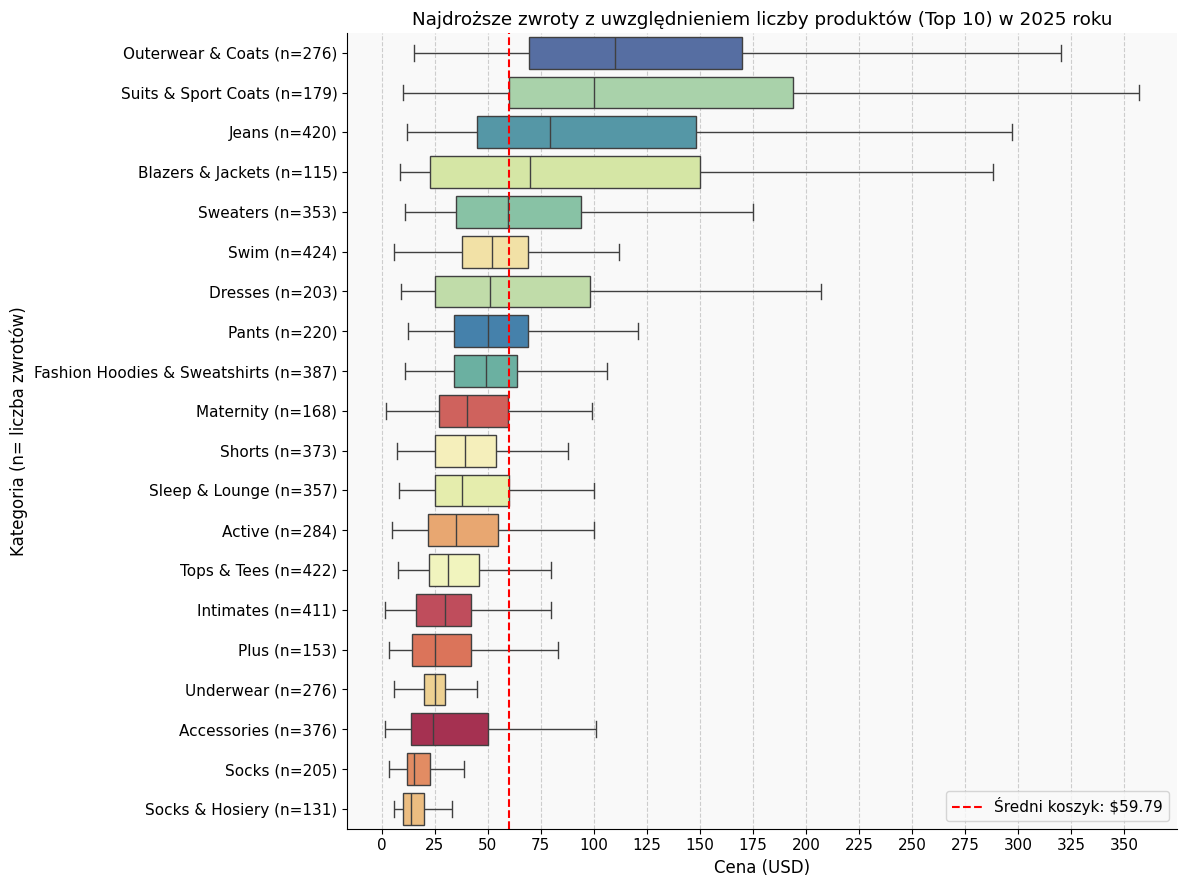

In [32]:
analyze_returned_items(engine, year=2025, show_outliers=False)

### 1. Kategorie o Krytycznym Ryzyku (Wysoka Wartość i Rosnący Wolumen)
* **Outerwear & Coats (Odzież wierzchnia i płaszcze):** Absolutny lider ryzyka. W 2025 roku liczba zwrotów wzrosła ze 170 do 276, a mediana ceny utrzymuje się powyżej 100 USD (znacznie powyżej średniej wielkości koszyka wynoszącej około 60,00$).
* **Suits & Sport Coats (Garnitury):** Charakteryzują się najwyższymi wartościami maksymalnymi (sięgającymi 350 USD). Choć wolumen jest mniejszy niż w innych kategoriach (n=179 w 2025 r.), koszt obsługi tych zwrotów jest najwyższy jednostkowo.
* **Jeans (Dżinsy):** Kategoria o wysokim ryzyku operacyjnym. Łączy stosunkowo wysoką medianę ceny z bardzo dużą skalą (wzrost z 247 do 420 zwrotów). To tutaj firma traci najwięcej na "masowości" drogich zwrotów. 

### 2. Kategorie o Wysokim Ryzyku Operacyjnym (Duża Skala)

* **Swim (Stroje kąpielowe) oraz Fashion Hoodies & Sweatshirts:** Obie kategorie odnotowały gwałtowny skok liczby zwrotów w 2025 roku (odpowiednio do 424 i 387 przypadków). Nawet jeśli ich cena oscyluje wokół średniej ($59.79), to łączny wolumen generuje potężne koszty procesowe.

### 3. Zmiany Tendencji (2024 vs 2025)
* **Wzrost kosztu średniego:** Średni koszt koszyka wzrósł z $59.31 do $59.79. Choć zmiana wydaje się niewielka, przy wzroście liczby zwrotów we wszystkich kluczowych kategoriach, całkowita ekspozycja finansowa firmy znacznie wzrosła.

* **Blazers & Jackets:** W 2025 r. kategoria ta awansowała w rankingu ryzyka finansowego (wyższa mediana i 115 zwrotów), wyprzedzając pod względem wartości dżinsy czy sukienki.
